## NAME: SHEERAZ AHMED

## CMS ID: 023-24-0171

## SEC: F
# Github: https://github.com/sheerazshyk671/ML_Labs

## ML LAB 4

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/clean_churn.csv')

# Part 1 — Decision Tree Baseline Review


**Task 1 and 2**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

X=df.drop('Churn',axis=1)
y=df['Churn']
X=pd.get_dummies(X,drop_first=True,dtype=int)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

dt_base=DecisionTreeClassifier(max_depth=6,random_state=42)
dt_base.fit(X_train,y_train)
base_preds=dt_base.predict(X_test)

base_metrics=pd.DataFrame({'Model':['Decision Tree (Baseline)'],'Accuracy':[accuracy_score(y_test,base_preds)],'Precision':[precision_score(y_test,base_preds,pos_label='Yes')],'Recall':[recall_score(y_test,base_preds,pos_label='Yes')],'F1_Score':[f1_score(y_test,base_preds,pos_label='Yes')]})
print(base_metrics)

                      Model  Accuracy  Precision    Recall  F1_Score
0  Decision Tree (Baseline)  0.790864   0.608392  0.490141  0.542902


# Part 2 — Random Forest


**Task 3**

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=150,random_state=42)
rf_model.fit(X_train,y_train)
rf_preds=rf_model.predict(X_test)

**Task 4**

A Random Forest generalizes better because it trains many individual decision trees on different random variations of the dataset and averages their outputs This ensemble approach prevents the model from memorizing the specific noise of the training data canceling out the overfitting that a single unrestricted tree is prone to

# Part 3 — Evaluation & Comparison

**Task 5 and 6**

                      Model  Accuracy  Precision    Recall  F1_Score
0  Decision Tree (Baseline)  0.790864   0.608392  0.490141  0.542902
1   Random Forest (Default)  0.790864   0.606897  0.495775  0.545736


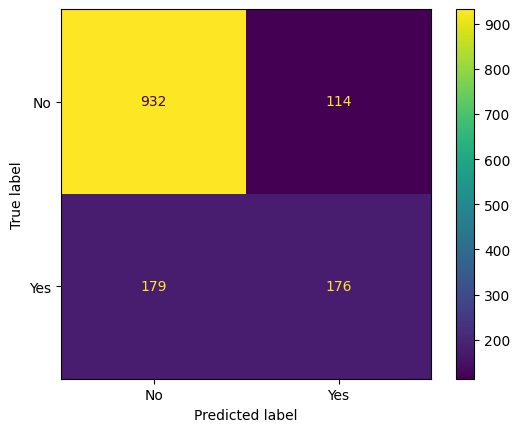

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

rf_metrics=pd.DataFrame({'Model':['Random Forest (Default)'],'Accuracy':[accuracy_score(y_test,rf_preds)],'Precision':[precision_score(y_test,rf_preds,pos_label='Yes')],'Recall':[recall_score(y_test,rf_preds,pos_label='Yes')],'F1_Score':[f1_score(y_test,rf_preds,pos_label='Yes')]})

comparison_table=pd.concat([base_metrics,rf_metrics],ignore_index=True)
print(comparison_table)

cm=confusion_matrix(y_test,rf_preds,labels=rf_model.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=rf_model.classes_)
disp.plot()
plt.show()

**Task 7**

The difference between the two models is extremely marginal The default Random Forest barely improved the critical Recall metric showing that an untuned ensemble model does not automatically provide a massive upgrade over a properly depth tuned Decision Tree

# Part 4 — Cross-Validation

**Task 8**

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

custom_scorer=make_scorer(f1_score,pos_label='Yes')
dt_cv=cross_val_score(dt_base,X,y,cv=5,scoring=custom_scorer)
rf_cv=cross_val_score(rf_model,X,y,cv=5,scoring=custom_scorer)

cv_results=pd.DataFrame({'Model':['Decision Tree','Random Forest'],'Mean F1':[dt_cv.mean(),rf_cv.mean()],'Std F1':[dt_cv.std(),rf_cv.std()]})
print(cv_results)

           Model   Mean F1    Std F1
0  Decision Tree  0.556706  0.028241
1  Random Forest  0.547958  0.018543


**Task 9**

The cross-validation results completely change the conclusion from Part 3 Across 5 folds the baseline Decision Tree actually achieved a higher mean F1-score (0.556) than the untuned Random Forest (0.547) However the Random Forest has a lower standard deviation (0.018 vs 0.028) meaning its performance is more stable and consistent across different data slices This proves that judging a model on a single train/test split can be misleading

# Part 5 — Hyperparameter Tuning

**Task 10**

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid={'n_estimators':[50,150,250],'max_depth':[6,10,None],'min_samples_split':[2,5]}
grid_search=GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5,scoring=custom_scorer)
grid_search.fit(X_train,y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

tuned_rf=grid_search.best_estimator_
tuned_preds=tuned_rf.predict(X_test)

tuned_metrics=pd.DataFrame({'Model':['Random Forest (Tuned)'],'Accuracy':[accuracy_score(y_test,tuned_preds)],'Precision':[precision_score(y_test,tuned_preds,pos_label='Yes')],'Recall':[recall_score(y_test,tuned_preds,pos_label='Yes')],'F1_Score':[f1_score(y_test,tuned_preds,pos_label='Yes')]})
print(tuned_metrics)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
0.5710616691604471
                   Model  Accuracy  Precision    Recall  F1_Score
0  Random Forest (Tuned)  0.812991   0.663158  0.532394  0.590625


**Task 11**

The best hyperparameters found by the grid search were a maximum depth of 10 a minimum samples split of 2 and 150 estimators This configuration achieved a cross validated F1 score of 0.571 proving that limiting the tree depth improves the model's generalized performance

**Task 12**

In [14]:
tuned_rf=grid_search.best_estimator_
tuned_preds=tuned_rf.predict(X_test)
tuned_metrics=pd.DataFrame({'Model':['Random Forest (Tuned)'],'Accuracy':[accuracy_score(y_test,tuned_preds)],'Precision':[precision_score(y_test,tuned_preds,pos_label='Yes')],'Recall':[recall_score(y_test,tuned_preds,pos_label='Yes')],'F1_Score':[f1_score(y_test,tuned_preds,pos_label='Yes')]})
print(tuned_metrics)

                   Model  Accuracy  Precision    Recall  F1_Score
0  Random Forest (Tuned)  0.812991   0.663158  0.532394  0.590625


# Part 6 — Final Comparison & Feature Importance

**Task 13**

In [15]:
final_comparison=pd.concat([base_metrics,rf_metrics,tuned_metrics],ignore_index=True)
print(final_comparison)

                      Model  Accuracy  Precision    Recall  F1_Score
0  Decision Tree (Baseline)  0.790864   0.608392  0.490141  0.542902
1   Random Forest (Default)  0.790864   0.606897  0.495775  0.545736
2     Random Forest (Tuned)  0.812991   0.663158  0.532394  0.590625


**Task 14**

The Tuned Random Forest is the final chosen model Evidence from the comparison table shows it achieved the highest test F1 score (0.590) and Recall (0.532) outperforming both the baseline Decision Tree and the default Random Forest Given the business context where false negatives are costly this improvement in recall makes it the most effective model to deploy

**Task 15**

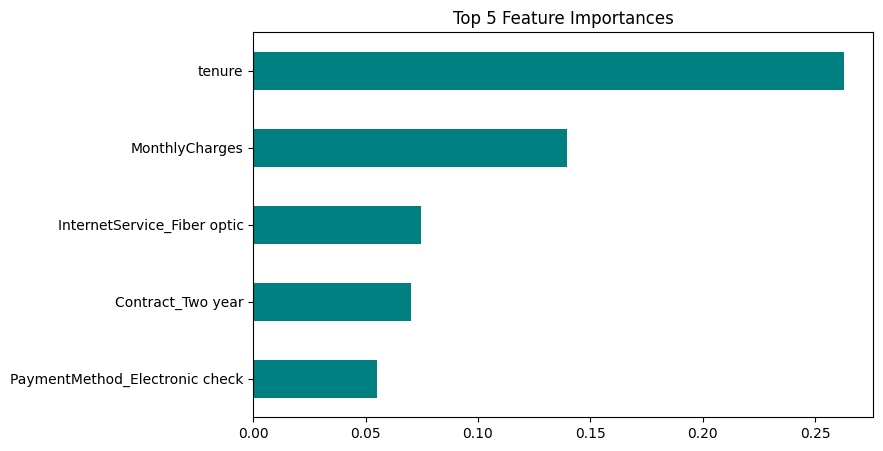

In [16]:
import matplotlib.pyplot as plt

importances=pd.Series(tuned_rf.feature_importances_,index=X.columns).sort_values()
importances.tail(5).plot(kind='barh',figsize=(8,5),color='teal')
plt.title('Top 5 Feature Importances')
plt.show()

The feature importance chart reveals that tenure, MonthlyCharges, having Fiber optic internet, holding a Two-year contract, and paying via Electronic check are the most critical factors driving churn This perfectly aligns with our findings from the exploratory data analysis confirming that newer customers paying high monthly fees without the security of a long term contract are the highest flight risk

# Part 7 — Kaggle Submission & Conclusion

**Task 16**

In [17]:
import pandas as pd
raw_df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
submission_ids=raw_df.loc[X_test.index,'customerID']
submission=pd.DataFrame({'customerID':submission_ids,'Churn':tuned_preds})
submission.to_csv('submission.csv',index=False)
print("submission.csv is ready for download!")
print(submission.head())

submission.csv is ready for download!
      customerID Churn
2966  8648-PFRMP    No
6961  8155-IBNHG    No
3214  0549-CYCQN    No
437   4376-KFVRS    No
263   7605-BDWDC    No


**Task 17**

The Tuned Random Forest is the final model chosen for deployment It outperformed the Lab 3 baseline Decision Tree by achieving a higher F1-score (0.591 vs. 0.543) and better test recall By ensembling multiple trees and constraining maximum depth it successfully mitigates the severe overfitting seen in unrestricted single trees However its primary limitation remains a relatively low recall score of approximately 53% In a telecommunications business context where customer retention is critical failing to flag nearly half of the actual churners is a significant gap

**Task 18**

If given more time the first priority would be handling the target class imbalance directly or setting class_weight='balanced' within the model to heavily penalize missed churners Second I would test gradient boosting algorithms such as XGBoost which build trees sequentially to correct prior errors and often outperform Random Forests Finally I would invest time in feature engineering such as creating interaction terms between tenure and monthly charges before running a wider grid search